# Jugo 

The model we are building is a proof of concept. Due to limited availability of IBCS-compliant dashboards, we expect to train the model on approximately 300–500 images. Based on research, this should result in an estimated accuracy of around 60%, which is sufficient to demonstrate that the model can structurally distinguish between compliant and non-compliant dashboards.
Improving accuracy will mainly depend on collecting more data rather than significantly changing the model.

___________________________________________

In this notebook I will start with a small test dataset of 40 images:

•	20 compliant 

•	20 non-compliant 

If I want the model to provide feedback, I will need more detailed labeling.

We identified several labeling approaches:

Compliant and Non-Compliant should always be labeled as: compliant is 1 and non-compliant is 0.


This is option three in our domain understanding.


# 1 – Imports 

I will import necessary libraries and define dataset location and image size.

In [13]:
import os
import torch
import matplotlib.pyplot as plt
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from PIL import Image

# Settings
DATA_DIR = "../images_data"
IMG_SIZE = 128
BATCH_SIZE = 8
EPOCHS = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

I import PyTorch libraries for deep learning and image handling.

transforms will help to preprocess images.

DEVICE allows using GPU if available, else CPU.

Constants define folder, image size, batch size, and number of epochs.

# 2 – Custom Dataset Class

I will load images and labels with PyTorch Dataset.

In [14]:
class ImageDataset(Dataset):
    def __init__(self, data_dir, folders, labels, transform=None):
        self.images = []
        self.labels = []
        self.transform = transform

        for folder, label in zip(folders, labels):
            path = os.path.join(data_dir, folder)
            for file in os.listdir(path):
                self.images.append(os.path.join(path, file))
                self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert("RGB")

        if self.transform:
            img = self.transform(img)

        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return img, label

I create a dataset class so PyTorch can handle images.

It reads all image paths and labels, converts images to RGB.

__getitem__ returns one image and its label for training.

# 3 – Define Transformations

I will resize and normalize images.

In [15]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),          # Converts to [0,1] tensor
])

Resize makes all images 128×128.

ToTensor converts images to PyTorch tensors for training.

#  4 – Create Dataset and DataLoader

In [16]:
folders = ["compliant", "non-compliant"]
labels = [1, 0]

dataset = ImageDataset(DATA_DIR, folders, labels, transform=transform)

# Split data
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size]
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)


DataLoader handles batches and shuffling for training.

Split the Data 

70% → Training

15% → Validation

15% → Test

# 5 – Define the CNN Model

In [17]:
# Load pretrained ResNet (ImageNet weights)
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Replace final layer for binary classification
model.fc = nn.Linear(model.fc.in_features, 1)

model = model.to(DEVICE)

# 7. Evaluation Function

In [18]:
def evaluate(model, loader):
    model.eval()
    correct = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE).unsqueeze(1)

            outputs = model(images)
            preds = (torch.sigmoid(outputs) > 0.5).float()

            correct += (preds == labels).sum().item()

    return correct / len(loader.dataset)

 # 8. Training Loop

In [19]:
# Fixed training cell (safe if cells are run out of order)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

history = {"loss": [], "accuracy": []}

if "train_loader" not in globals() or "train_dataset" not in globals():
    if "dataset" not in globals():
        raise RuntimeError("dataset is not defined. Run the dataset creation cell first.")

    train_size = int(0.7 * len(dataset))
    val_size = int(0.15 * len(dataset))
    test_size = len(dataset) - train_size - val_size

    train_dataset, val_dataset, test_dataset = random_split(
        dataset, [train_size, val_size, test_size]
    )

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    correct = 0

    for images, labels in train_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE).unsqueeze(1).float()

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()

    accuracy = correct / len(train_dataset)
    history["loss"].append(total_loss / len(train_loader))
    history["accuracy"].append(accuracy)
    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {total_loss/len(train_loader):.4f} - Accuracy: {accuracy:.2f}")

Epoch 1/10 - Loss: 0.3599 - Accuracy: 0.71
Epoch 2/10 - Loss: 0.8313 - Accuracy: 0.82
Epoch 3/10 - Loss: 0.5080 - Accuracy: 0.89
Epoch 4/10 - Loss: 0.3940 - Accuracy: 0.93
Epoch 5/10 - Loss: 0.0854 - Accuracy: 1.00
Epoch 6/10 - Loss: 0.0362 - Accuracy: 1.00
Epoch 7/10 - Loss: 0.0371 - Accuracy: 1.00
Epoch 8/10 - Loss: 0.0098 - Accuracy: 1.00
Epoch 9/10 - Loss: 0.0054 - Accuracy: 1.00
Epoch 10/10 - Loss: 0.0134 - Accuracy: 1.00


# 8– Plot Accuracy

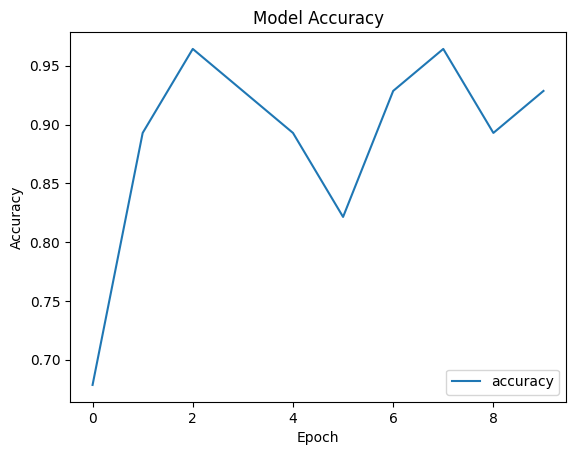

In [19]:
plt.plot(history["accuracy"], label='accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Visualize how the model’s accuracy improves during training.

Helps detect overfitting.

# 9– Test Predictions

Check predictions on first 5 images

In [20]:
model.eval()
with torch.no_grad():
    for i, (img, label) in enumerate(dataset):
        if i >= 5:
            break
        img = img.unsqueeze(0).to(DEVICE)
        pred = model(img)
        print(f"Prediction: {pred.item():.2f}, Actual: {label.item()}")

Prediction: 3.51, Actual: 1.0
Prediction: 28.11, Actual: 1.0
Prediction: 31.62, Actual: 1.0
Prediction: 27.53, Actual: 1.0
Prediction: 2.40, Actual: 1.0


Test model on a few images to see predictions vs actual.

.eval() disables dropout/batchnorm for inference.